In [1]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from weightedtraining.instancepipeline import get_data_loaders
from weightedtraining.finalfulltrain import EarthquakeCNN, evaluate_metrics,evaluate_by_magnitude

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = PROJECT_ROOT / "weightedtraining" / "data" / "best_model_weighted.pth"

checkpoint = torch.load(checkpoint_path, map_location=device)
model = EarthquakeCNN().to(device)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()




Train samples: 979487
Validation samples: 96993
Test samples: 82769
Train batches: 7653
Val batches: 758
Test batches: 647


EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [2]:
train_loader, val_loader, test_loader = get_data_loaders()

In [3]:
test_35_mae, test_35_rmse, test_35_bias, test_35_count = evaluate_by_magnitude(
    model,
    test_loader,
    device,
    magnitude_threshold=3.5
)

test_40_mae, test_40_rmse, test_40_bias, test_40_count = evaluate_by_magnitude(
    model,
    test_loader,
    device,
    magnitude_threshold=4.0)

In [4]:
print(
    f"Test M >= 3.5 | "
    f"MAE: {test_35_mae:.4f} | "
    f"RMSE: {test_35_rmse:.4f} | "
    f"Bias: {test_35_bias:.4f} | "
    f"N: {test_35_count}"
)

print(
    f"Test M >= 4.0 | "
    f"MAE: {test_40_mae:.4f} | "
    f"RMSE: {test_40_rmse:.4f} | "
    f"Bias: {test_40_bias:.4f} | "
    f"N: {test_40_count}"
)

Test M >= 3.5 | MAE: 0.6752 | RMSE: 0.8546 | Bias: -0.5849 | N: 3322
Test M >= 4.0 | MAE: 0.6738 | RMSE: 0.9018 | Bias: -0.6401 | N: 986


In [5]:
import pandas as pd

In [11]:
all_predictions = []
all_targets = []

model.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in test_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)


        predictions = model(waveforms).squeeze(-1)


        magnitudes = magnitudes + TARGET_MEAN
        predictions = predictions + TARGET_MEAN
        

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

In [12]:
print(results[["true_magnitude", "predicted_magnitude"]].mean())

true_magnitude         2.217452
predicted_magnitude    2.246415
dtype: float32


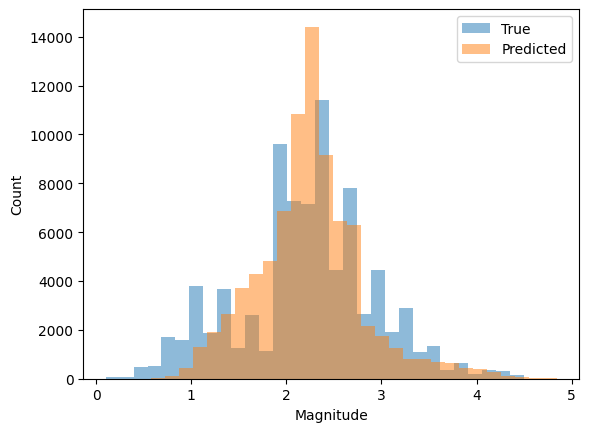

In [13]:
import matplotlib.pyplot as plt

plt.hist(results["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [14]:
results["error"] = (
    results["predicted_magnitude"]
    - results["true_magnitude"]
)

results["bin"] = pd.cut(
    results["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",6130,0.689486,0.652290
"(1, 2]",22281,0.268340,0.246689
"(2, 3]",45138,-0.074919,-0.073657
"(3, 4]",8407,-0.463887,-0.499319
"(4, 5]",813,-0.647719,-0.481125


In [15]:
results["error"] = (
    results["predicted_magnitude"] -
    results["true_magnitude"]
)
for low in range(6):
    mask = (
        (results["true_magnitude"] >= low) &
        (results["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results.loc[mask, "error"].abs().mean(),
        "bias =", results.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.7486057 bias = 0.7471858
1-2 count = 15919 MAE = 0.41278914 bias = 0.36130017
2-3 count = 51082 MAE = 0.2841651 bias = -0.028623581
3-4 count = 10339 MAE = 0.58455235 bias = -0.44305745
4-5 count = 986 MAE = 0.6737781 bias = -0.64008284
5-6 count = 0 MAE = nan bias = nan


In [20]:
results["error"]

0       -0.031801
1        0.478777
2        0.297482
3        0.035646
4        0.156340
           ...   
82764    0.920128
82765    0.660427
82766    0.534803
82767    0.070938
82768    0.373359
Name: error, Length: 82769, dtype: float32

In [18]:
results["error"].count()

np.int64(82769)

In [25]:
bin4 = results[results["true_magnitude"] > 4]

In [26]:
bin4["error"].count()

np.int64(813)

In [ ]:
(bin4["error"] < 0.3).sum()

np.int64(809)

In [29]:
import torch
import pandas as pd
import numpy as np


def evaluate_model_by_bins(
    model,
    dataloader,
    device,
    target_mean
):
    model.eval()

    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for waveforms, magnitudes in dataloader:

            waveforms = waveforms.to(
                device,
                non_blocking=True
            )

            magnitudes = magnitudes.to(
                device,
                non_blocking=True
            )

            predictions = model(
                waveforms
            ).squeeze(-1)

            # Convert both back to actual magnitude scale
            actual_predictions = (
                predictions + target_mean
            )

            actual_magnitudes = (
                magnitudes + target_mean
            )

            all_predictions.append(
                actual_predictions.cpu()
            )

            all_targets.append(
                actual_magnitudes.cpu()
            )


    all_predictions = torch.cat(
        all_predictions
    ).numpy()

    all_targets = torch.cat(
        all_targets
    ).numpy()


    results = pd.DataFrame({
        "magnitude": all_targets,
        "prediction": all_predictions
    })


    results["error"] = (
        results["prediction"]
        - results["magnitude"]
    )

    results["absolute_error"] = (
        results["error"].abs()
    )


    bins = [
        0,
        1,
        2,
        3,
        4,
        5,
        6
    ]

    labels = [
        "0-1",
        "1-2",
        "2-3",
        "3-4",
        "4-5",
        "5-6"
    ]

    results["bin"] = pd.cut(
        results["magnitude"],
        bins=bins,
        labels=labels,
        right=True,
        include_lowest=True
    )


    print("\nOverall")

    overall_mae = (
        results["absolute_error"].mean()
    )

    overall_bias = (
        results["error"].mean()
    )

    overall_rmse = np.sqrt(
        np.mean(
            results["error"] ** 2
        )
    )

    accuracy_02 = (
        results["absolute_error"] <= 0.2
    ).mean() * 100


    print(
        f"MAE = {overall_mae:.6f}"
    )

    print(
        f"RMSE = {overall_rmse:.6f}"
    )

    print(
        f"Bias = {overall_bias:.6f}"
    )

    print(
        f"Accuracy ±0.2 = "
        f"{accuracy_02:.2f}%"
    )


    print("\nBy magnitude bin")

    bin_results = []

    for label in labels:

        subset = results[
            results["bin"] == label
        ]

        count = len(subset)

        if count == 0:

            mae = np.nan
            rmse = np.nan
            bias = np.nan

        else:

            mae = (
                subset["absolute_error"].mean()
            )

            rmse = np.sqrt(
                np.mean(
                    subset["error"] ** 2
                )
            )

            bias = (
                subset["error"].mean()
            )


        bin_results.append({
            "bin": label,
            "count": count,
            "MAE": mae,
            "RMSE": rmse,
            "bias": bias
        })


        print(
            f"{label} "
            f"count = {count} "
            f"MAE = {mae:.6f} "
            f"RMSE = {rmse:.6f} "
            f"bias = {bias:.6f}"
        )


    bin_results = pd.DataFrame(
        bin_results
    )

    return results, bin_results

In [30]:

weighted_results, weighted_bins = evaluate_model_by_bins(
    model,
    test_loader,
    device,
    TARGET_MEAN
)


Overall
MAE = 0.375998
RMSE = 0.498059
Bias = 0.028963
Accuracy ±0.2 = 36.80%

By magnitude bin
0-1 count = 6130 MAE = 0.692475 RMSE = 0.795475 bias = 0.689486
1-2 count = 22281 MAE = 0.349777 RMSE = 0.443479 bias = 0.268340
2-3 count = 45138 MAE = 0.297735 RMSE = 0.399181 bias = -0.074919
3-4 count = 8407 MAE = 0.605793 RMSE = 0.723565 bias = -0.463887
4-5 count = 813 MAE = 0.677306 RMSE = 0.912441 bias = -0.647719
5-6 count = 0 MAE = nan RMSE = nan bias = nan


In [31]:
from pathlib import Path
import sys
import torch 

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0,str(PROJECT_ROOT))

from weightedtraining.instancepipeline import get_data_loaders
from weightedtraining.finalfulltrain import EarthquakeCNN, evaluate_metrics,evaluate_by_magnitude

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path2 = PROJECT_ROOT / "weightedtraining" / "data" / "best_model_weighted2.pth"

checkpoint2 = torch.load(checkpoint_path2, map_location=device)
model2 = EarthquakeCNN().to(device)

model2.load_state_dict(checkpoint2["model_state_dict"])

model2.eval()




EarthquakeCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv1d(3, 16, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (4): Sequential(
      (0): Conv1d(128, 256, kernel_size=(5,), stride=(1,), padding=(2,))
      (1): ReLU()
      (2): MaxPool1d(kernel_size=2, str

In [32]:

weighted_results2, weighted_bins2 = evaluate_model_by_bins(
    model2,
    test_loader,
    device,
    TARGET_MEAN
)


Overall
MAE = 0.375956
RMSE = 0.498797
Bias = 0.011368
Accuracy ±0.2 = 36.63%

By magnitude bin
0-1 count = 6130 MAE = 0.664816 RMSE = 0.775076 bias = 0.663025
1-2 count = 22281 MAE = 0.345604 RMSE = 0.437681 bias = 0.256924
2-3 count = 45138 MAE = 0.296338 RMSE = 0.398766 bias = -0.091411
3-4 count = 8407 MAE = 0.645676 RMSE = 0.755326 bias = -0.504522
4-5 count = 813 MAE = 0.661116 RMSE = 0.906491 bias = -0.590770
5-6 count = 0 MAE = nan RMSE = nan bias = nan


In [33]:
all_predictions = []
all_targets = []

model2.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in test_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        # model predicts centered magnitude
        predictions = model2(waveforms).squeeze(-1)

        # convert BOTH back to actual magnitude
        
        predictions = predictions + TARGET_MEAN
        magnitudes = magnitudes + TARGET_MEAN
        

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

results2 = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

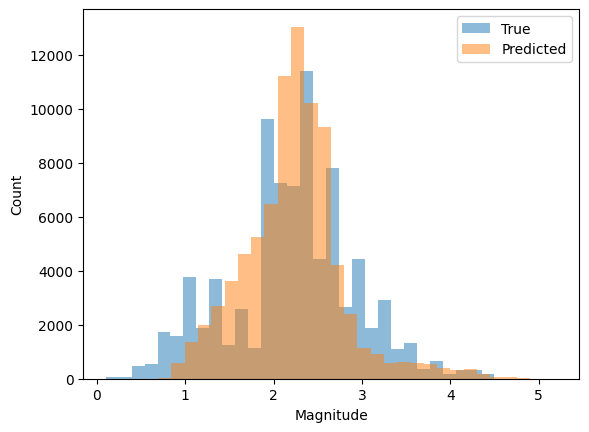

In [34]:
import matplotlib.pyplot as plt

plt.hist(results2["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(results2["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [35]:
print(results2["true_magnitude"].describe())
print(results2["predicted_magnitude"].describe())

count    82769.000000
mean         2.217452
std          0.714146
min          0.100000
25%          2.000000
50%          2.200000
75%          2.600000
max          4.500000
Name: true_magnitude, dtype: float64
count    82769.000000
mean         2.228821
std          0.557367
min          0.694048
25%          1.910232
50%          2.237554
75%          2.513805
max          5.203251
Name: predicted_magnitude, dtype: float64


In [36]:
results2["error"] = (
    results2["predicted_magnitude"]
    - results2["true_magnitude"]
)

results2["bin"] = pd.cut(
    results2["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

results2.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",6130,0.663025,0.625932
"(1, 2]",22281,0.256924,0.240431
"(2, 3]",45138,-0.091411,-0.084044
"(3, 4]",8407,-0.504522,-0.568154
"(4, 5]",813,-0.590770,-0.416923


In [37]:
results2["error"] = (
    results2["predicted_magnitude"] -
    results2["true_magnitude"]
)
for low in range(6):
    mask = (
        (results2["true_magnitude"] >= low) &
        (results2["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results2.loc[mask, "error"].abs().mean(),
        "bias =", results2.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.72029054 bias = 0.71994245
1-2 count = 15919 MAE = 0.40250275 bias = 0.34644926
2-3 count = 51082 MAE = 0.2828607 bias = -0.0431374
3-4 count = 10339 MAE = 0.61902595 bias = -0.48151988
4-5 count = 986 MAE = 0.6700201 bias = -0.59930533
5-6 count = 0 MAE = nan bias = nan


In [38]:
all_predictions = []
all_targets = []

model2.eval()
TARGET_MEAN = 2.28802128052746
with torch.no_grad():
    for waveforms, magnitudes in val_loader:
        waveforms = waveforms.to(device)
        magnitudes = magnitudes.to(device)

        # model predicts centered magnitude
        predictions = model2(waveforms).squeeze(-1)

        # convert BOTH back to actual magnitude
        
        predictions = predictions + TARGET_MEAN
        magnitudes = magnitudes + TARGET_MEAN
        

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(magnitudes.cpu().numpy())

resultsval = pd.DataFrame({
    "true_magnitude": all_targets,
    "predicted_magnitude": all_predictions
})

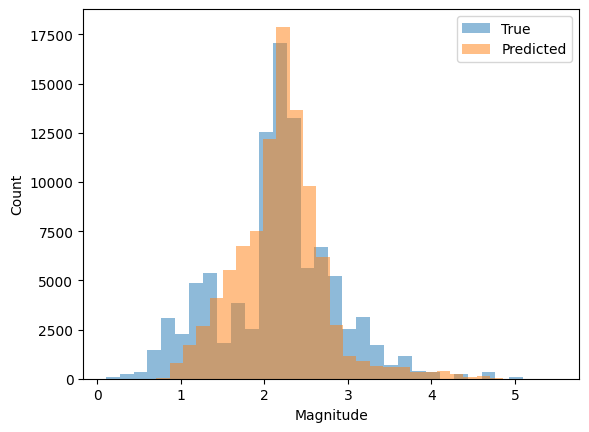

In [40]:
import matplotlib.pyplot as plt

plt.hist(resultsval["true_magnitude"], bins=30, alpha=0.5, label="True")
plt.hist(resultsval["predicted_magnitude"], bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.legend()
plt.show()

In [41]:
resultsval["error"] = (
    resultsval["predicted_magnitude"]
    - resultsval["true_magnitude"]
)

resultsval["bin"] = pd.cut(
    results2["true_magnitude"],
    bins=[0, 1, 2, 3, 4, 5, 6]
)

resultsval.groupby("bin", observed=True)["error"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
bin,,,
"(0, 1]",6130,0.044331,0.055559
"(1, 2]",22281,0.041823,0.048568
"(2, 3]",45138,0.063329,0.068248
"(3, 4]",8407,0.087110,0.076794
"(4, 5]",813,0.046223,0.041235


In [42]:
results2["error"] = (
    results2["predicted_magnitude"] -
    results2["true_magnitude"]
)
for low in range(6):
    mask = (
        (results2["true_magnitude"] >= low) &
        (results2["true_magnitude"] < low + 1)
    )

    print(
        f"{low}-{low+1}",
        "count =", mask.sum(),
        "MAE =", results2.loc[mask, "error"].abs().mean(),
        "bias =", results2.loc[mask, "error"].mean()
    )

0-1 count = 4443 MAE = 0.72029054 bias = 0.71994245
1-2 count = 15919 MAE = 0.40250275 bias = 0.34644926
2-3 count = 51082 MAE = 0.2828607 bias = -0.0431374
3-4 count = 10339 MAE = 0.61902595 bias = -0.48151988
4-5 count = 986 MAE = 0.6700201 bias = -0.59930533
5-6 count = 0 MAE = nan bias = nan


In [43]:
resultsval.to_csv("resultsvalbeta5.csv")

In [ ]:
results.to_csv("resultstestbeta5.csv")